<a href="https://colab.research.google.com/github/Ayman-Ewas/Supervised-Assignment-2-CNN-/blob/main/20230081_20230717_2023_CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning Course Assignment 2

| Name | ID |
|------|----|
|  Mohamed Beshr Al Sofi | 20230717  |
|  Ayman Sayed Abd-Elmonem | 20230081  |


In [1]:
# ── Setup & Data Loading ──────────────────────────────────────────────────
# Import required libraries and load the CIFAR-10 dataset.
# The dataset is split into 40 000 training, 10 000 validation,
# and 10 000 test images (32×32 RGB).

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


In [2]:
# Global plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi':      120,
    'axes.titlesize':  14,
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})


In [3]:
# ── Helper Functions ──────────────────────────────────────────────────────
# train_and_evaluate() compiles, trains, and evaluates a Keras model, then
# reports test accuracy, test loss, and total training time.
# plot_curves() draws training / validation metric curves for comparison.

def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te, epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()

    # Determine loss type to handle labels correctly
    is_sparse = model.loss == 'sparse_categorical_crossentropy'
    y_tr_proc = y_tr if is_sparse else to_categorical(y_tr, 10)
    y_v_proc = y_v if is_sparse else to_categorical(y_v, 10)
    y_te_proc = y_te if is_sparse else to_categorical(y_te, 10)

    history = model.fit(x_tr, y_tr_proc,
                        validation_data=(x_v, y_v_proc),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=cb, verbose=0
                        )

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, y_te_proc, verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time:{elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def BaselineCNN():
  model = models.Sequential([
      layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
      layers.MaxPooling2D((2, 2)),
      layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
      layers.MaxPooling2D((2, 2)),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])

  model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  return model

In [ ]:
# Min-Max Scaler
from sklearn.preprocessing import MinMaxScaler
minMax = MinMaxScaler()

x_train_minMax = minMax.fit_transform(x_train.reshape(-1, 32*32*3))
x_val_minMax = minMax.transform(x_val.reshape(-1, 32*32*3))
x_test_minMax = minMax.transform(x_test.reshape(-1, 32*32*3))

# Reshaping
x_train_minMax = x_train_minMax.reshape(-1, 32, 32, 3)
x_val_minMax = x_val_minMax.reshape(-1, 32, 32, 3)
x_test_minMax = x_test_minMax.reshape(-1, 32, 32, 3)

In [ ]:
# Standrdiaztion
from sklearn.preprocessing import StandardScaler
standard = StandardScaler()

x_train_standard = standard.fit_transform(x_train.reshape(-1, 32*32*3))
x_val_standard = standard.transform(x_val.reshape(-1, 32*32*3))
x_test_standard = standard.transform(x_test.reshape(-1, 32*32*3))

# Reshaping
x_train_standard = x_train_standard.reshape(-1, 32, 32, 3)
x_val_standard = x_val_standard.reshape(-1, 32, 32, 3)
x_test_standard = x_test_standard.reshape(-1, 32, 32, 3)

In [ ]:
# Training normal data
model = BaselineCNN()
history, test_acc, test_loss, elapsed = train_and_evaluate(model, x_train, y_train, x_val, y_val, x_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.5790 | Test Loss: 2.8443 | Time:865.7s


In [ ]:
# Training minMax scaled data
model = BaselineCNN()
history_minMax, test_acc_minMax, test_loss_minMax, elapsed_minMax = train_and_evaluate(model, x_train_minMax, y_train, x_val_minMax, y_val, x_test_minMax, y_test)

Test Acc: 0.6553 | Test Loss: 1.5818 | Time:1363.3s


In [ ]:
# Training standardized data
model = BaselineCNN()
history_standard, test_acc_standard, test_loss_standard, elapsed_standard = train_and_evaluate(model, x_train_standard, y_train, x_val_standard, y_val, x_test_standard, y_test)

Test Acc: 0.6526 | Test Loss: 2.0862 | Time:1376.3s


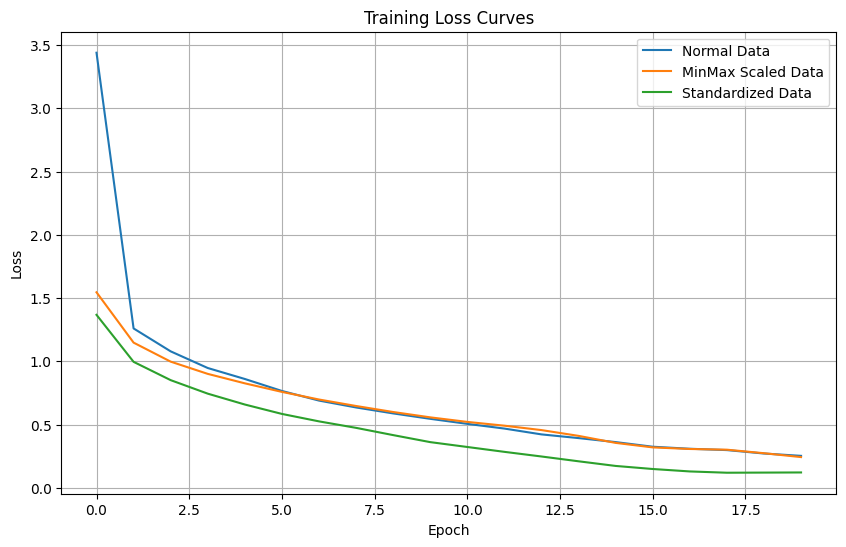

In [ ]:
# Plots
histories = [history, history_minMax, history_standard]
labels = ['Normal Data', 'MinMax Scaled Data', 'Standardized Data']

# Loss Plots
plot_curves(histories, labels, metric='loss', title='Training Loss Curves', ylabel='Loss')



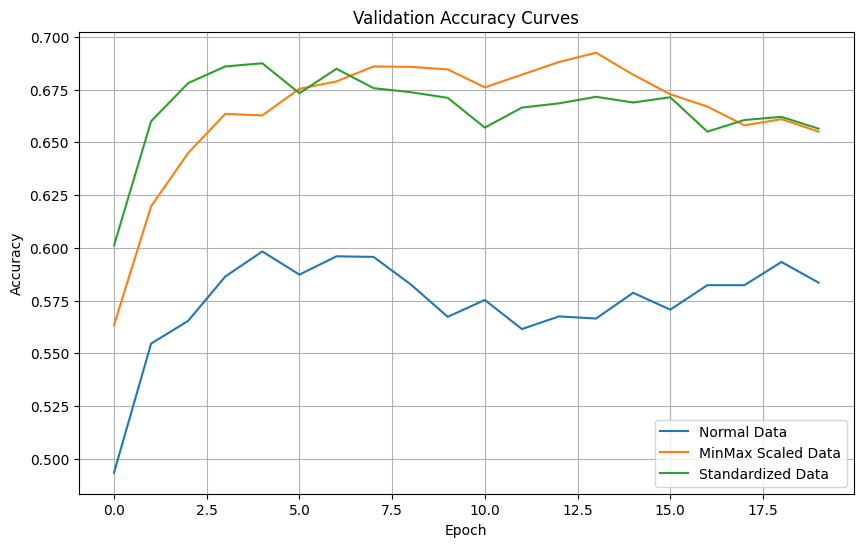

In [ ]:
# Accuracy plots
plot_curves(histories, labels, title='Validation Accuracy Curves', ylabel='Accuracy')

In [ ]:
# Generating table
import pandas as pd
Data = {"Train Acc": [history.history['accuracy'][-1], history_minMax.history['accuracy'][-1], history_standard.history['accuracy'][-1]],
        "Val Acc" : [history.history['val_accuracy'][-1], history_minMax.history['val_accuracy'][-1], history_standard.history['val_accuracy'][-1]],
        "Test Acc": [test_acc, test_acc_minMax, test_acc_standard],
        "Loss @ epoch 1": [history.history['loss'][0], history_minMax.history['loss'][0], history_standard.history['loss'][0]]}
index = ["None [0-255]", "MinMax [0,1]", "Standardized"]
df = pd.DataFrame(Data, index=index)
df

,Train Acc,Val Acc,Test Acc,Loss @ epoch 1
None [0-255],"[0.39684998989105225, 0.5485749840736389, 0.61...","[0.4934000074863434, 0.5546000003814697, 0.565...",0.5790,3.438654
"MinMax [0,1]","[0.443574994802475, 0.5962749719619751, 0.6538...","[0.5633999705314636, 0.619700014591217, 0.6449...",0.6553,1.545659
Standardized,"[0.5152750015258789, 0.6547250151634216, 0.705...","[0.6011000275611877, 0.6600000262260437, 0.678...",0.6526,1.367492


In [ ]:
def Augmented():
  datagen = tf.keras.preprocessing.image.ImageDataGenerator(
  rotation_range=15,
  width_shift_range=0.1,
  height_shift_range=0.1,
  horizontal_flip=True,
  zoom_range=0.1
  )
  datagen.fit(x_train_standard)
  return datagen

In [ ]:
# Training with augmented data
model_aug = BaselineCNN()
datagen = Augmented()
augmented_train_generator = datagen.flow(x_train_standard, to_categorical(y_train, 10), batch_size=128)

start_aug = time.time()
history_aug = model_aug.fit(augmented_train_generator,
                            validation_data=(x_val_standard, to_categorical(y_val, 10)),
                            epochs=40,
                            verbose=0)
elapsed_aug = time.time() - start_aug

test_loss_aug, test_acc_aug = model_aug.evaluate(x_test_standard, to_categorical(y_test, 10), verbose=0)
print(f"Test Acc: {test_acc_aug:.4f} | Test Loss: {test_loss_aug:.4f} | Time: {elapsed_aug:.1f}s")

In [ ]:
# Training with standardized data (no augmented)
model = BaselineCNN()
history_non_aug, test_acc_non_aug, test_loss_non_aug, elapsed_non_aug = train_and_evaluate(model, x_train_standard, y_train, x_val_standard, y_val, x_test_standard, y_test, epochs=40)

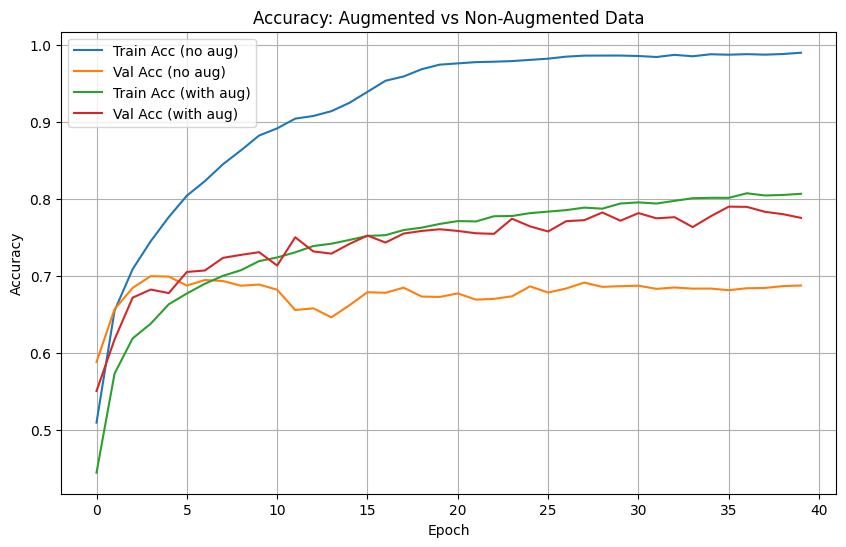

In [ ]:
# Plotting 4 curves
plt.figure(figsize=(10, 6))
plt.plot(history_non_aug.history['accuracy'], label='Train Acc (no aug)')
plt.plot(history_non_aug.history['val_accuracy'], label='Val Acc (no aug)')
plt.plot(history_aug.history['accuracy'], label='Train Acc (with aug)')
plt.plot(history_aug.history['val_accuracy'], label='Val Acc (with aug)')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy: Augmented vs Non-Augmented Data')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Non-augmented gap
gap_non_aug = history_non_aug.history['accuracy'][39] - history_non_aug.history['val_accuracy'][39]

# Augmented gap
gap_aug = history_aug.history['accuracy'][39] - history_aug.history['val_accuracy'][39]

print(f"Non-Augmented gap at epoch 40: {gap_non_aug:.4f}")
print(f"Augmented gap at epoch 40: {gap_aug:.4f}")

# Augmentation reduced gap. Then, it overfits less

Non-Augmented gap at epoch 40: 0.3026
Augmented gap at epoch 40: 0.0313


## **Task2 -> build model**

### part A

In [4]:
# Imports
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Dropout

In [ ]:
# ── Part A – Width Experiment ─────────────────────────────────────────────
# Build and train three CNN variants with increasing filter widths
# (small: 8/16, medium: 16/32, large: 24/48 filters per block).
# Each model has two Conv blocks followed by a Flatten + Dense head.


partA_models = []
for i in range(1,4):
    model = Sequential([
        Conv2D(filters= i * 8, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= i * 8, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= i * 8 * 2, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= i * 8 * 2, kernel_size=3, padding = 'same', activation= 'relu'),

        Flatten(),
        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')
    ])

    model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )
    print(model.summary())
    model.fit(x_train,y_train,epochs=20,batch_size=128,validation_data=(x_val,y_val))
    partA_models.append(model)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,055,698 (4.03 MB)

 Trainable params: 1,055,698 (4.03 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20


KeyboardInterrupt: 

In [ ]:
# ── Part A – Evaluate Accuracy ───────────────────────────────────────────
# Run inference on the test set for each Part-A model and record accuracy.

from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracy_scores = []
name_models = ['small','medium','large']
for i,model in enumerate(partA_models):
    y_pred = model.predict(x_test)
    y_pred = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)


In [ ]:
# ── Part A – Visualise Results ───────────────────────────────────────────
# Plot a bar chart comparing the test accuracy of the three CNN widths.

# Create the bar plot with different colors
plt.figure(figsize=(8, 5))
plt.bar(name_models, accuracy_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Accuracy of Models on Test Data')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1) # Accuracy scores are between 0 and 1
plt.show()

### Part C

In [ ]:
# ── Part C – Depth & Pooling Experiment ──────────────────────────────────
# Define three CNN architectures that explore increasing depth and the
# effect of Global Average Pooling (GAP) as a replacement for Flatten.
#   Model 1: 2 Conv blocks + Flatten (baseline)
#   Model 2: 3 Conv blocks + 1× GAP
#   Model 3: 4 Conv blocks + 2× GAP

from tensorflow.keras.layers import GlobalAveragePooling2D
partC_models = [
    Sequential([
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        Flatten(),
        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')]),

    Sequential([
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        GlobalAveragePooling2D(),

        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')]),

    Sequential([
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        MaxPool2D(pool_size=(2,2)),

        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),
        GlobalAveragePooling2D(),

        Dense(units=256, activation='relu'),
        Dense(10, activation = 'softmax')])
    ]

In [ ]:
# ── Part C – Compile & Train ──────────────────────────────────────────────
# Compile all Part-C models with Adam + sparse categorical cross-entropy
# and train for 20 epochs; store each training history for later analysis.

history = []
for i,model in enumerate(partC_models):
    model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )
    print(model.summary())
    history.append(model.fit(x_train,y_train,epochs=20,batch_size=128,validation_data=(x_val,y_val)))

In [ ]:
# ── Part C – Training / Validation Loss Curves ───────────────────────────
# Plot side-by-side loss curves (train vs. val) for all three Part-C models
# to inspect overfitting behaviour as depth increases.

# Depth loss Comparison
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
model_names = ['Model 1 (Flatten)', 'Model 2 (1xGAP)', 'Model 3 (2xGAP)']

for i, h in enumerate(history):
    axs[i].plot(h.history['loss'], label='Train Loss')
    axs[i].plot(h.history['val_loss'], label='Val Loss')
    axs[i].set_title(f'{model_names[i]} Loss')
    axs[i].set_xlabel('Epoch')
    axs[i].set_ylabel('Loss')
    axs[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Part C – Evaluate Test Accuracy ──────────────────────────────────────
# Compute and print the test-set accuracy for each Part-C model.

from sklearn.metrics import accuracy_score

accuracy_scores = []
for i, model in enumerate(partC_models):
    y_pred = model.predict(x_test)
    y_pred = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test.flatten(), y_pred)
    accuracy_scores.append(accuracy)
    print(f"Model {i+1} Accuracy: {accuracy:.4f}")

In [ ]:
# ── Part C – Visualise Accuracy Comparison ───────────────────────────────
# Bar chart comparing the test accuracy of the three depth/pooling variants.

# Create the bar plot with different colors
plt.figure(figsize=(8, 5))
plt.bar(name_models, accuracy_scores, color=plt.cm.plasma(np.linspace(0.2, 0.8, len(name_models))))
plt.title('Accuracy of Models on Test Data')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.show()

# Task 3 -> Regularization

### Part A

In [8]:
# No dropout (D0)
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history = model.fit(x_train,y_train,epochs=30,batch_size=128,validation_data=(x_val,y_val))
train_acc = history.history['accuracy'][29]
val_acc = history.history['val_accuracy'][29]
gap = train_acc - val_acc
_, test_acc = model.evaluate(x_test, y_test, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.3084 - loss: 3.5631 - val_accuracy: 0.4216 - val_loss: 1.6377
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4956 - loss: 1.4046 - val_accuracy: 0.5171 - val_loss: 1.3681
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5966 - loss: 1.1391 - val_accuracy: 0.5361 - val_loss: 1.3555
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6717 - loss: 0.9332 - val_accuracy: 0.5192 - val_loss: 1.5594
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7244 - loss: 0.7784 - val_accuracy: 0.5405 - val_loss: 1.5963
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7713 - loss: 0.6549 - val_accuracy: 0.5472 - val_loss: 1.7957
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8209 - loss: 0.5186 - val_accuracy: 0.5353 - val_loss: 2.0727
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8661 - loss: 0.3881 - va

In [24]:
# After maxpool, rate = 0.25  (D1)
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dropout(0.25),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history_025 = model.fit(x_train,y_train,epochs=30,batch_size=128,validation_data=(x_val,y_val))
train_acc_025 = history_025.history['accuracy'][29]
val_acc_025 = history_025.history['val_accuracy'][29]
gap_025 = train_acc_025 - val_acc_025
_, test_acc_025 = model.evaluate(x_test, y_test, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.2118 - loss: 3.4222 - val_accuracy: 0.3750 - val_loss: 1.7769
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4313 - loss: 1.5629 - val_accuracy: 0.4892 - val_loss: 1.4132
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5211 - loss: 1.3203 - val_accuracy: 0.5551 - val_loss: 1.2499
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5926 - loss: 1.1453 - val_accuracy: 0.5848 - val_loss: 1.1676
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6398 - loss: 1.0215 - val_accuracy: 0.6274 - val_loss: 1.0603
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6767 - loss: 0.9146 - val_accuracy: 0.6478 - val_loss: 1.0313
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7143 - loss: 0.8102 - val_accuracy: 0.6549 - val_loss: 1.0083
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7424 - loss: 0.7313 - va

In [25]:
# After maxpool, rate = 0.5  (D2)
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),
    Dropout(0.5),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dropout(0.5),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history_05 = model.fit(x_train,y_train,epochs=30,batch_size=128,validation_data=(x_val,y_val))
train_acc_05 = history_05.history['accuracy'][29]
val_acc_05 = history_05.history['val_accuracy'][29]
gap_05 = train_acc_05 - val_acc_05
_, test_acc_05 = model.evaluate(x_test, y_test, verbose=0)

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.1703 - loss: 3.4937 - val_accuracy: 0.3239 - val_loss: 1.8406
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3527 - loss: 1.7502 - val_accuracy: 0.4062 - val_loss: 1.6433
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4331 - loss: 1.5498 - val_accuracy: 0.4974 - val_loss: 1.4035
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4904 - loss: 1.3999 - val_accuracy: 0.5388 - val_loss: 1.2821
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5354 - loss: 1.2855 - val_accuracy: 0.5597 - val_loss: 1.2317
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5645 - loss: 1.2093 - val_accuracy: 0.5995 - val_loss: 1.1203
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5939 - loss: 1.1369 - val_accuracy: 0.6212 - val_loss: 1.0586
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6129 - loss: 1.0828 - va

In [29]:
data = {"Train Acc" : [history.history['accuracy'][-1], history_025.history['accuracy'][-1], history_05.history['accuracy'][-1]],
        "Val Acc"   : [history.history['val_accuracy'][-1], history_025.history['val_accuracy'][-1], history_05.history['val_accuracy'][-1]],
        "Test Acc"  : [test_acc, test_acc_025, test_acc_05],
        "Overfit Gap": [gap, gap_025, gap_05]}
index = ["D0", "D1", "D2"]
df = pd.DataFrame(data, index=index)
df

,Train Acc,Val Acc,Test Acc,Overfit Gap
D0,0.981550,0.5901,0.5892,0.439525
D1,0.953950,0.6639,0.6627,0.290050
D2,0.856725,0.7109,0.7091,0.145825


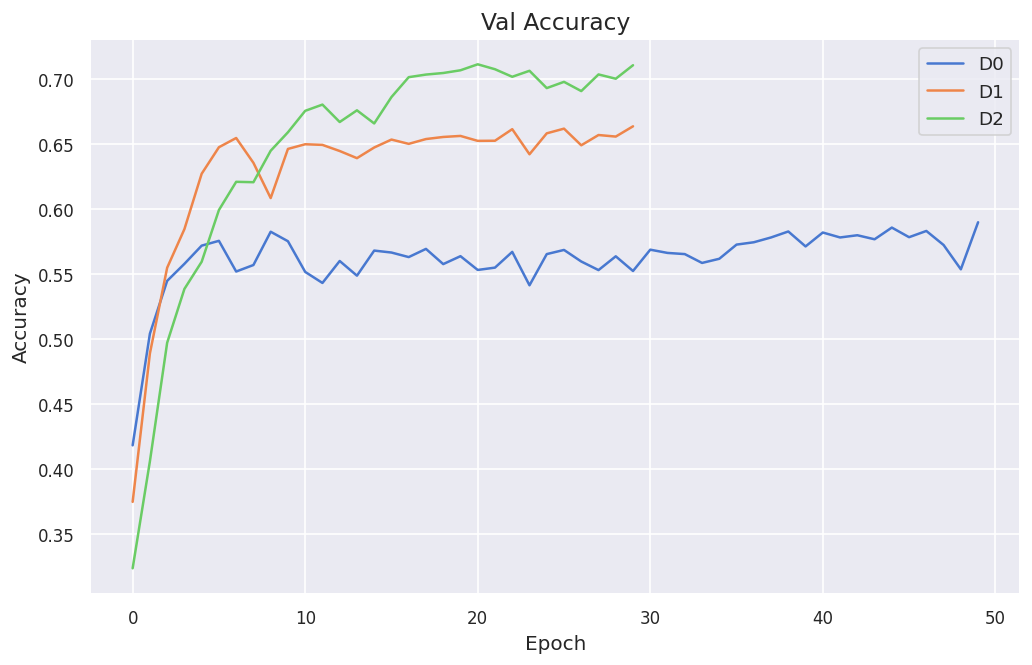

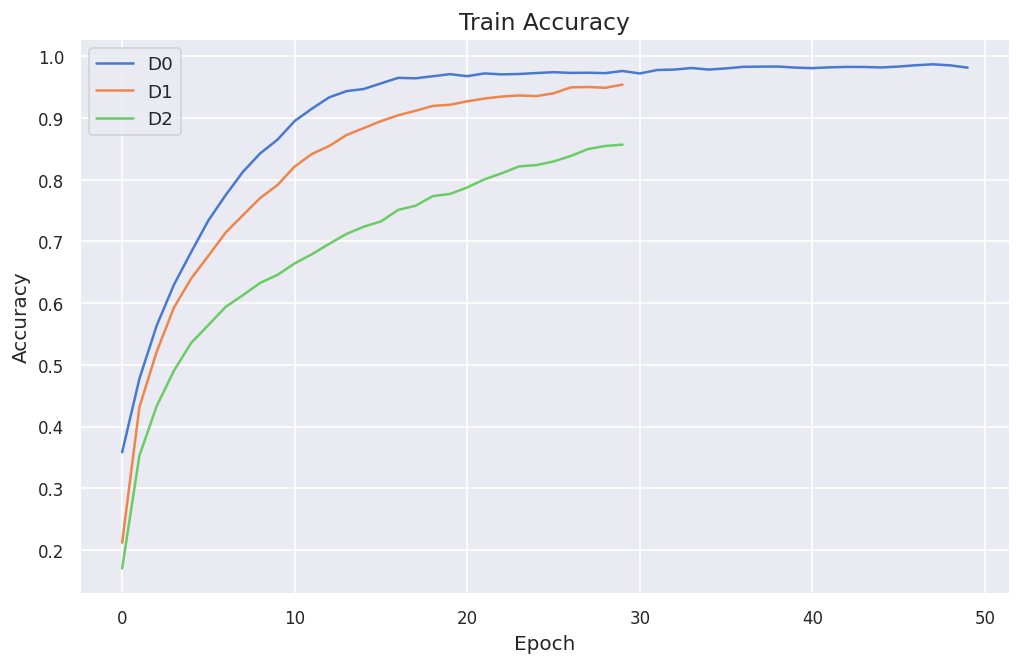

In [27]:
histories = [history, history_025, history_05]
labels = ['D0', 'D1', 'D2']
plot_curves(histories, labels, title='Val Accuracy', ylabel='Accuracy')
plot_curves(histories, labels,metric = 'accuracy', title='Train Accuracy', ylabel='Accuracy')

In [28]:
min_gap = min([gap, gap_025, gap_05])
if min_gap == gap:
  print("D0 is best")
elif min_gap == gap_025:
  print("D1 is best")
else:
  print("D2 is best")

D2 is best


### Part B

In [13]:
# ES0 No early stopping
start = time.time()
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history = model.fit(x_train,y_train,epochs=50,batch_size=128,validation_data=(x_val,y_val))
_, test_acc = model.evaluate(x_test, y_test, verbose=0)
elapsed = time.time() - start

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.3584 - loss: 2.4524 - val_accuracy: 0.4185 - val_loss: 1.5983
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.4774 - loss: 1.4472 - val_accuracy: 0.5044 - val_loss: 1.3767
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5635 - loss: 1.2237 - val_accuracy: 0.5450 - val_loss: 1.2894
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6296 - loss: 1.0474 - val_accuracy: 0.5581 - val_loss: 1.2683
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6827 - loss: 0.9003 - val_accuracy: 0.5721 - val_loss: 1.2512
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7340 - loss: 0.7599 - val_accuracy: 0.5758 - val_loss: 1.3028
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7750 - loss: 0.6386 - val_accuracy: 0.5522 - val_loss: 1.5209
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8127 - loss: 0.5330 - v

In [15]:
# ES2
start_es2 = time.time()
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])
es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history_es2 = model.fit(x_train,y_train,epochs=50,batch_size=128,validation_data=(x_val,y_val), callbacks=[es])
_, test_acc_es2 = model.evaluate(x_test, y_test, verbose=0)
elapsed_es2 = time.time() - start_es2

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.3446 - loss: 3.3235 - val_accuracy: 0.4486 - val_loss: 1.5457
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4832 - loss: 1.4401 - val_accuracy: 0.5000 - val_loss: 1.4185
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5568 - loss: 1.2414 - val_accuracy: 0.5313 - val_loss: 1.3312
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6242 - loss: 1.0699 - val_accuracy: 0.5429 - val_loss: 1.3678
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6808 - loss: 0.9011 - val_accuracy: 0.5397 - val_loss: 1.4578
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7333 - loss: 0.7665 - val_accuracy: 0.5039 - val_loss: 1.7098
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7720 - loss: 0.6584 - val_accuracy: 0.5113 - val_loss: 1.7892
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8162 - loss: 0.5320 - va

In [14]:
# ES3
start_es3 = time.time()
model = Sequential([
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu', input_shape=(32, 32, 3)),
    Conv2D(filters= 32, kernel_size=3, padding = 'same', activation= 'relu'),

    MaxPool2D(pool_size=(2,2)),

    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),
    Conv2D(filters= 64, kernel_size=3, padding = 'same', activation= 'relu'),

    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation = 'softmax')
])
es = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights = True)
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
print(model.summary())
history_es3 = model.fit(x_train,y_train,epochs=50,batch_size=128,validation_data=(x_val,y_val), callbacks = [es])
_, test_acc_es3 = model.evaluate(x_test, y_test, verbose=0)
elapsed_es3 = time.time() - start_es3

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,262,698 (16.26 MB)

 Trainable params: 4,262,698 (16.26 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.3557 - loss: 2.8281 - val_accuracy: 0.4589 - val_loss: 1.4958
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5149 - loss: 1.3419 - val_accuracy: 0.5232 - val_loss: 1.3328
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6087 - loss: 1.0972 - val_accuracy: 0.5617 - val_loss: 1.2512
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6776 - loss: 0.9137 - val_accuracy: 0.5548 - val_loss: 1.3283
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7315 - loss: 0.7708 - val_accuracy: 0.5442 - val_loss: 1.4310
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7739 - loss: 0.6464 - val_accuracy: 0.5515 - val_loss: 1.5977
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8142 - loss: 0.5298 - val_accuracy: 0.5483 - val_loss: 1.8113
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8453 - loss: 0.4405 - va

In [17]:
loss_es0 = []
for i in history.history['val_loss']:
  loss_es0.append(i)
min_es0 = min(loss_es0)

loss_es2 = []
for i in history_es2.history['val_loss']:
  loss_es2.append(i)
min_es2 = min(loss_es2)

loss_es3 = []
for i in history_es3.history['val_loss']:
  loss_es3.append(i)
min_es3 = min(loss_es3)

In [19]:
import pandas as pd
data = {"Stopped at epoch": [len(history.history['loss']), len(history_es2.history['loss']), len(history_es3.history['loss'])],
        "Best Val loss"   : [min_es0, min_es2, min_es3],
        "Test_Acc"        : [test_acc, test_acc_es2, test_acc_es3],
        "Time(s)"         : [elapsed, elapsed_es2, elapsed_es3]}
index = ["ES0", "ES2", "ES3"]
df = pd.DataFrame(data, index=index)
df


,Stopped at epoch,Best Val loss,Test_Acc,Time(s)
ES0,50,1.251244,0.5892,252.283088
ES2,8,1.331178,0.5314,45.957293
ES3,13,1.251240,0.5593,68.097230


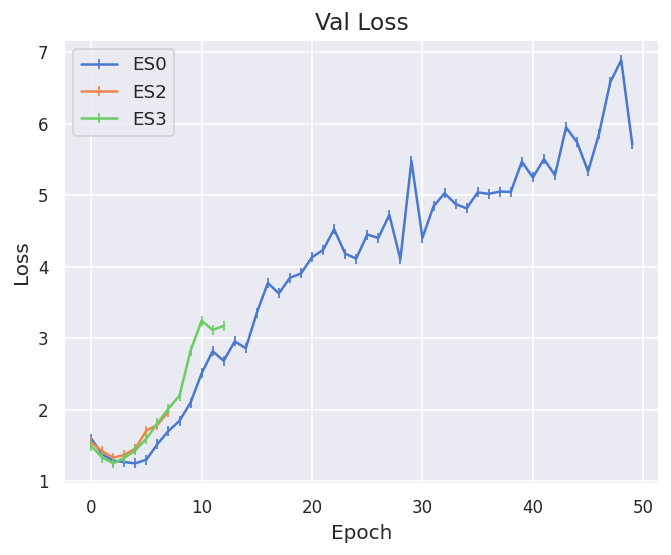

In [23]:
histories = [history, history_es2, history_es3]
labels = ['ES0', 'ES2', 'ES3']
# plot_curves(histories, labels, metric = 'val_loss', title='Val Loss', ylabel='Accuracy')
plt.plot(history.history['val_loss'], label='ES0', marker = '|')
plt.plot(history_es2.history['val_loss'], label='ES2', marker = '|')
plt.plot(history_es3.history['val_loss'], label='ES3', marker = '|')
plt.title('Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# From the results patience=5 is really aggresive as it stops too early
# patience=10 is not too lenient, it's regular

# **Task4 -> Optimizers**
### Part A



In [ ]:
# ── Part D – Optimizer Experiment (Setup) ────────────────────────────────
# Define a dictionary of optimizers to compare:
# SGD, SGD+Momentum, AdaGrad, RMSProp, and Adam — all at the same LR.

# Define optimizer factories to avoid reusing optimizer objects across different models
optimizer_factories = {
    'SGD':keras.optimizers.SGD(learning_rate=0.001),
    'Momentum':keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad':keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp':keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam':keras.optimizers.Adam(learning_rate=0.001),
}

In [ ]:
# ── Part D – Train with Different Optimizers ─────────────────────────────
# Re-build the medium CNN architecture and train one copy per optimizer.
# Results (accuracy, loss, time) are stored for comparison.

medium_model_base = Sequential([
    layers.Input(shape=(32, 32, 3)),
    Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'),
    Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'),
    Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'),
    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(10, activation='softmax')
])

results = {}

for opt_name, optimizer in optimizer_factories.items():
    print(f"\n--- Training with Optimizer: {opt_name} ---")
    model = medium_model_base

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'],
                  )

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train, y_train, x_val, y_val, x_test, y_test,
        epochs=20, batch_size=128
    )
    results[opt_name] = history

# Plot all curves together for comparison
plot_curves(list(results.values()), list(results.keys()), title='Optimizer Comparison - Validation Accuracy')

## Part B

In [ ]:
# ── Part D – Learning-Rate Sweep (Adam) ──────────────────────────────────
# Train the medium CNN with Adam at three learning rates
# (0.0001, 0.001, 0.01) to study the effect on convergence.

learning_rates = [0.0001,0.001,0.01]
results = {}

for i in learning_rates:
  print(f"Learning Rate: {i} for Adam optimizer")
  model = medium_model_base
  model.compile(optimizer=keras.optimizers.Adam(learning_rate=i),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'],
                )

  history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train, y_train, x_val, y_val, x_test, y_test,
        epochs=30, batch_size=128
    )
  results[i] = history

plot_curves(list(results.values()), list(results.keys()), title='Learning Rate Comparison - Validation Accuracy')